In [1]:
import pandas as pd
import numpy as np
import io

#Read digit from digit.csv
from google.colab import files
uploaded = files.upload()



Saving digit.csv to digit.csv


In [2]:
import pandas as pd
df = pd.read_csv(io.BytesIO(uploaded["digit.csv"]),header=None)

In [3]:
df


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


Show First digit

In [4]:
print(np.reshape(np.array(df.iloc[0,:-1]),[28,28]))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253
  159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252
  252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239
  233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202
   84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 25

In [5]:
import matplotlib.pyplot as plt


Reshape 500x784 --> 10 x 50 x 784
                   digit x Number    x pixel

In [6]:
digit =np.reshape(np.array(df.iloc[:,:-1]),[10,50,784]) # ignore the last column since it is a label

Visualized a digit



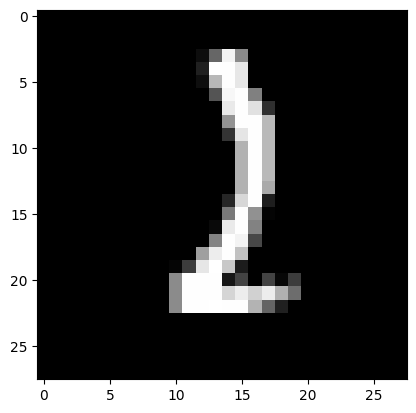

In [7]:
plt.imshow(np.reshape(digit[2,15,:],[28,28]),cmap='gray')
plt.show()

Try Visualize one of digit 3

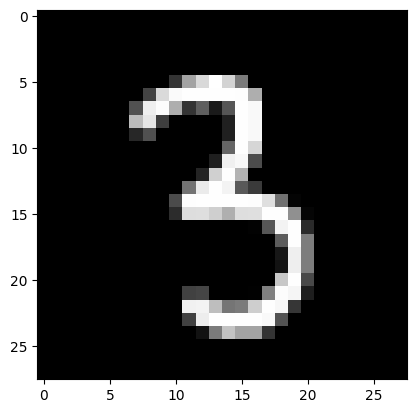

In [8]:
plt.imshow(np.reshape(digit[3,15,:],[28,28]),cmap='gray')

In [9]:
print(digit[0,:,:].shape)

(50, 784)


## Binarize the digit

In [10]:
bin_digit=1*(digit>128)

# Create train data (80%/20%)

In [11]:
number0=np.mean(bin_digit[0,:40,:],axis=0)#  P(D|0)
number1=np.mean(bin_digit[1,:40,:],axis=0)# P(D|1)

print(number0.shape)

(784,)


In [12]:
print(number0)


[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.025 0.    0.    0.025 0.025 0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.025 0.025 0.125 0.275 0.2   0.275 0.35  0.35  0.25  0.075
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.05  0.075 0.225 0.35  0.5   0.675 0.75
 0.7   0.65  0.5   0.35  0.175 0.05  0.    0.    0.    0.    0.    0.
 0.    0.    0.

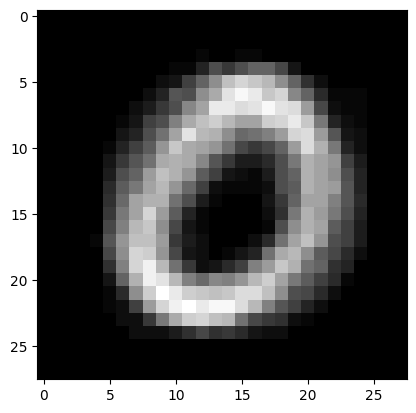

In [13]:
plt.imshow(np.reshape(number0,[28,28]),cmap='gray')

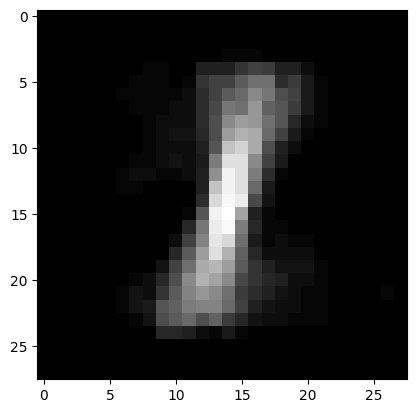

In [14]:
plt.imshow(np.reshape(number1,[28,28]),cmap='gray')

In [15]:
print(np.reshape(number1,[28,28]))

[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.025 0.025 0.025 0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.025 0.025 0.    0.
  0.125 0.125 0.125 0.2   0.25  0.225 0.125 0.125 0.05  0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.025 0.025 0.025 0.    0.025
  0.2   0.25  0.25  0.35  0.425 0.425 0.175 0.225 0.1   0.025 0.    0.
  0.    0.

In [29]:
(1-digit[0,40:,:])*(1-number0)

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [47]:
# p(0|number) = p(digit|0) p(0) /   (p(0|digit) p(0)+ p(1|digit) p(1))
p0 = np.prod(bin_digit[0,40:,:]*number0+(1-bin_digit[0,40:,:])*(1-number0),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(bin_digit[0,40:,:]*number1+(1-bin_digit[0,40:,:])*(1-number1),axis=1)*.5 # p(digit|1) p(1)
# this is using input as digit 0 * probability of being 0 for each bits
prob0=p0/(p0+p1)
prob1=p1/(p0+p1)

/tmp/ipython-input-2223695456.py:5: RuntimeWarning: invalid value encountered in divide
  prob0=p0/(p0+p1)
/tmp/ipython-input-2223695456.py:6: RuntimeWarning: invalid value encountered in divide
  prob1=p1/(p0+p1)


In [48]:
print(np.array([prob0 ,prob1]).T)


[[ 1.  0.]
 [ 1.  0.]
 [nan nan]
 [nan nan]
 [ 1.  0.]
 [ 1.  0.]
 [nan nan]
 [nan nan]
 [nan nan]
 [ 1.  0.]]


np.mean(digit)

In [41]:
p0 = np.prod(bin_digit[1,40:,:]*number0+(1-bin_digit[1,40:,:])*(1-number0),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(bin_digit[1,40:,:]*number1+(1-bin_digit[1,40:,:])*(1-number1),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)

In [42]:
print(np.array([prob0 ,prob1]).T)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


Try with all digits

In [32]:
number=[]
for i in range(10):
  number.append(np.mean(bin_digit[i,:40,:],axis=0))

In [92]:
#
p = []
p_total = 0
for i in range(10):
  p_digit = np.prod(bin_digit[0,:40,:]*number[i]+(1-bin_digit[0,:40,:])*(1-number[i]),axis=1)*.1 # p(digit|number) p(number)
  p.append(p_digit)
  print(p_digit)
  p_total += p_digit
# left expression is when pixel = 1 right is when =0

[4.44765414e-060 1.48737941e-072 1.41769614e-100 1.89307428e-080
 4.06044816e-081 2.81165087e-083 3.53461067e-102 7.78183500e-113
 2.47855612e-081 4.01152064e-074 4.90811169e-072 5.29905002e-079
 2.56435269e-064 2.87046460e-113 1.95223110e-079 2.66023003e-067
 7.50068114e-080 2.06794574e-101 1.52431864e-089 4.98477615e-075
 2.21269763e-064 3.19671219e-093 1.88642140e-090 4.72663100e-075
 5.22717685e-088 1.68824839e-090 3.37514541e-092 6.51703901e-077
 6.84830312e-118 2.41208614e-093 6.40960294e-101 5.97919143e-082
 1.00325623e-069 9.80879096e-070 9.43390067e-062 1.56235752e-065
 1.09591521e-057 5.25248276e-062 9.76002913e-079 3.46290381e-071]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.00000000e+000 0.00000000e+000 5.43794588e-107 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+00

In [94]:
prob = p/p_total
print(np.argmax(prob, axis=0))
print(np.argmax(prob, axis=0).shape)

[0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0
 0 0 0]
(40,)




```
# This is formatted as code
```

# Estimate from the first 40 digits